In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Facebook_Marketplace_data.csv to Facebook_Marketplace_data (1).csv


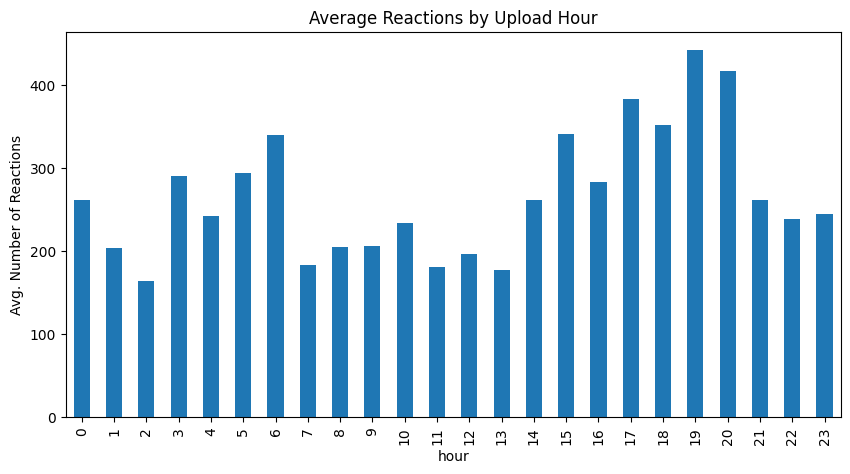

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('Facebook_Marketplace_data.csv')


df['status_published'] = pd.to_datetime(df['status_published'])
df['hour'] = df['status_published'].dt.hour


hourly_reactions = df.groupby('hour')['num_reactions'].mean()

plt.figure(figsize=(10,5))
hourly_reactions.plot(kind='bar')
plt.ylabel('Avg. Number of Reactions')
plt.title('Average Reactions by Upload Hour')
plt.show()

               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


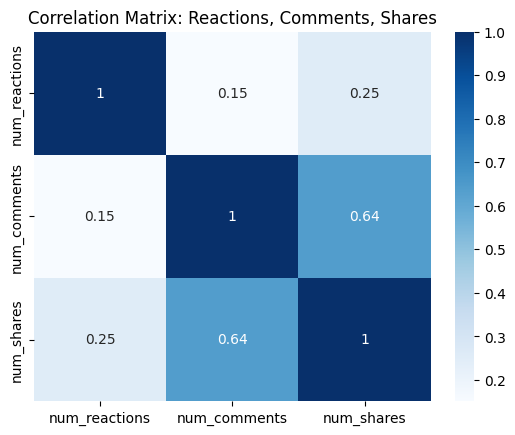

In [ ]:

engagement_cols = ['num_reactions', 'num_comments', 'num_shares']
correlations = df[engagement_cols].corr()

print(correlations)

import seaborn as sns
sns.heatmap(correlations, annot=True, cmap='Blues')
plt.title('Correlation Matrix: Reactions, Comments, Shares')
plt.show()

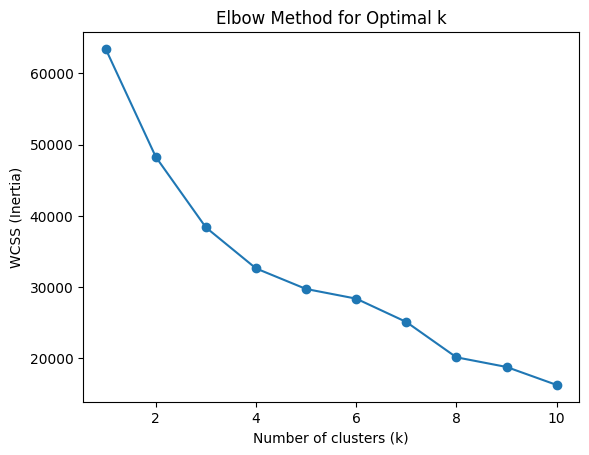

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


features = [
    'num_reactions', 'num_comments', 'num_shares',
    'num_likes', 'num_loves', 'num_wows', 'num_hahas',
    'num_sads', 'num_angrys'
]
X = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    'status_type', 'num_reactions', 'num_comments', 'num_shares',
    'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys'
]

data = df[features].copy()


data['status_type_code'] = data['status_type'].astype('category').cat.codes


data_for_clustering = data.drop('status_type', axis=1)


data_for_clustering = data_for_clustering.fillna(0)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_for_clustering)


kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


df['cluster'] = clusters

print(df[['status_type', 'num_reactions', 'num_comments', 'num_shares', 'cluster']].head())

  status_type  num_reactions  num_comments  num_shares  cluster
0       video            529           512         262        1
1       photo            150             0           0        0
2       video            227           236          57        0
3       photo            111             0           0        0
4       photo            213             0           0        0


In [ ]:
import pandas as pd

post_counts = df['status_type'].value_counts()

print(post_counts)

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


In [ ]:
import pandas as pd

averages = (
    df.groupby('status_type')[['num_reactions', 'num_comments', 'num_shares']]
    .mean()
    .reset_index()
)

print(averages)

  status_type  num_reactions  num_comments  num_shares
0        link     370.142857      5.698413    4.396825
1       photo     181.290345     15.993470    2.553871
2      status     438.783562     36.238356    2.558904
3       video     283.409597    642.478149  115.679949
